**Анализ сайта «СберАвтоподписка»**

**Цель проекта**
Построить модель, предсказывающую вероятность того, что пользователь совершит целевое действие на сайте.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

# 1.Загрузка данных

In [3]:
BASE_DIR = Path(".")
SESSIONS_PATH = BASE_DIR / "ga_sessions.csv"
HITS_AGG_PATH = BASE_DIR / "ga_hits_aggregated.csv"

ga_sessions = pd.read_csv(SESSIONS_PATH)
hits_agg = pd.read_csv(HITS_AGG_PATH)

print("Размер ga_sessions:", ga_sessions.shape)
print("Размер hits_agg:", hits_agg.shape)

display(ga_sessions.head())
display(hits_agg.head())

C:\Users\Русик\AppData\Local\Temp\ipykernel_3096\4203367899.py:5: DtypeWarning: Columns (0: client_id) have mixed types. Specify dtype option on import or set low_memory=False.
  ga_sessions = pd.read_csv(SESSIONS_PATH)


Размер ga_sessions: (1860042, 18)
Размер hits_agg: (1734610, 5)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


,session_id,hits_count,pages_count,event_count,has_target
0,1000009318903347362.1632663668.1632663668,10,3,10,0
1,1000010177899156286.1635013443.1635013443,6,2,6,0
2,1000013386240115915.1635402956.1635402956,11,3,11,0
3,1000017303238376207.1623489300.1623489300,12,3,12,0
4,1000020580299877109.1624943350.1624943350,1,1,1,0


# 2.Объединение и первичная обработка

In [4]:
df = ga_sessions.merge(hits_agg, on="session_id", how="left")

df["has_target"] = df["has_target"].fillna(0).astype(int)
df["hits_count"] = df["hits_count"].fillna(0)
df["pages_count"] = df["pages_count"].fillna(0)
df["event_count"] = df["event_count"].fillna(0)

print("Размер объединенной таблицы:", df.shape)
print(df["has_target"].value_counts())
print(df["has_target"].value_counts(normalize=True))

display(df.head())

Размер объединенной таблицы: (1860042, 22)
has_target
0    1809728
1      50314
Name: count, dtype: int64
has_target
0    0.97295
1    0.02705
Name: proportion, dtype: float64


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,hits_count,pages_count,event_count,has_target
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,2.0,1.0,2.0,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,1.0,1.0,1.0,0
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,16.0,2.0,16.0,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,3.0,1.0,3.0,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,2.0,1.0,2.0,0


# 3.EDA

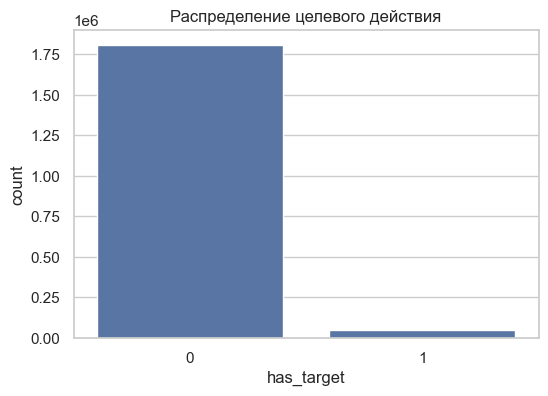

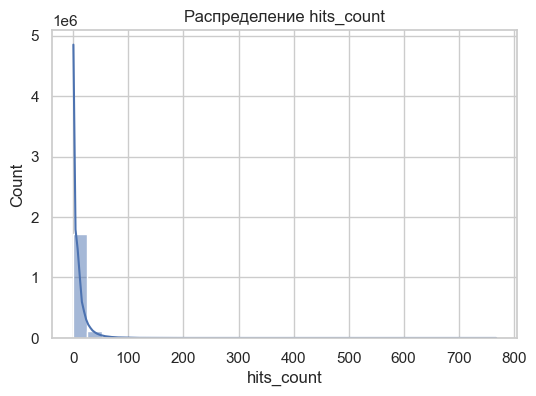

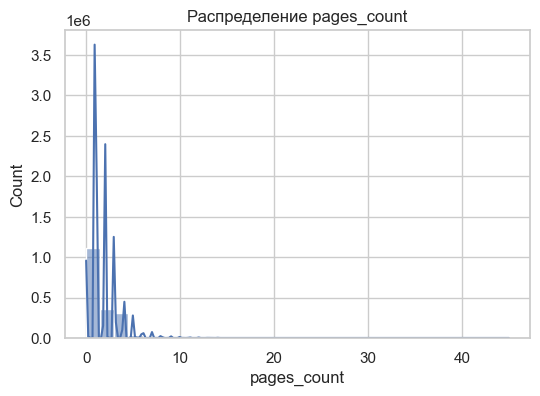

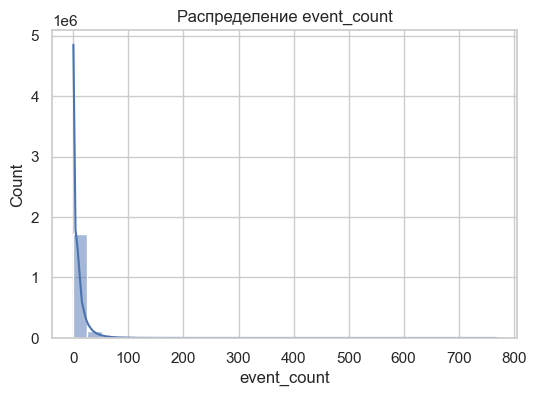

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="has_target", data=df)
plt.title("Распределение целевого действия")
plt.show()

for col in ["hits_count", "pages_count", "event_count"]:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Распределение {col}")
    plt.show()

**Вывод по EDA**

После объединения данных по визитам и событиям была получена итоговая таблица для анализа.  
Распределение целевой переменной показало, что целевое действие встречается существенно реже, чем его отсутствие.  
Также видно, что поведенческие признаки, такие как количество событий, просмотренных страниц и общее число хитов, потенциально могут быть полезны для модели.

# 4.Подготовка данных

In [6]:
drop_cols = []
for col in ["session_id", "client_id"]:
    if col in df.columns:
        drop_cols.append(col)

df_model = df.drop(columns=drop_cols)

y = df_model["has_target"]
X = df_model.drop(columns=["has_target"])

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

if len(num_cols) > 0:
    num_imputer = SimpleImputer(strategy="median")
    X[num_cols] = num_imputer.fit_transform(X[num_cols])

if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

selected_cat_cols = []
for col in ["utm_medium", "device_category", "device_os", "device_browser", "geo_country"]:
    if col in X.columns:
        selected_cat_cols.append(col)

selected_cols = num_cols + selected_cat_cols
X = X[selected_cols].copy()
X = X.loc[:, ~X.columns.duplicated()]

cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

for col in X.columns:
    if X[col].dtype == "float64":
        X[col] = X[col].astype("float32")
    elif X[col].dtype == "int64":
        X[col] = X[col].astype("int32")
    elif X[col].dtype == "bool":
        X[col] = X[col].astype("int8")

print("Размер после кодирования:", X.shape)
display(X.head())

Размер после кодирования: (1860042, 294)


,visit_number,hits_count,pages_count,event_count,utm_medium_(not set),utm_medium_CPM,utm_medium_Sbol_catalog,utm_medium_app,utm_medium_article,utm_medium_banner,utm_medium_blogger_channel,utm_medium_blogger_header,utm_medium_blogger_stories,utm_medium_catalogue,utm_medium_cbaafe,utm_medium_clicks,utm_medium_cpa,utm_medium_cpc,utm_medium_cpm,utm_medium_cpv,utm_medium_desktop,utm_medium_dom_click,utm_medium_email,utm_medium_fb_smm,utm_medium_google_cpc,utm_medium_info_text,utm_medium_landing,utm_medium_landing_interests,utm_medium_last,utm_medium_link,utm_medium_linktest,utm_medium_main_polka,utm_medium_medium,utm_medium_nkp,utm_medium_ok_smm,utm_medium_organic,utm_medium_outlook,utm_medium_partner,utm_medium_post,utm_medium_promo_sber,utm_medium_promo_sbol,utm_medium_push,utm_medium_qr,utm_medium_qrcodevideo,utm_medium_reach,utm_medium_referral,utm_medium_sber_app,utm_medium_smartbanner,utm_medium_smm,utm_medium_sms,utm_medium_social,utm_medium_static,utm_medium_stories,utm_medium_tablet,utm_medium_tg,utm_medium_users_msk,utm_medium_vk_smm,utm_medium_web_polka,utm_medium_yandex_cpc,device_category_mobile,device_category_tablet,device_os_Android,device_os_BlackBerry,device_os_Chrome OS,device_os_Firefox OS,device_os_Linux,device_os_Macintosh,device_os_Nokia,device_os_Samsung,device_os_Tizen,device_os_Windows,device_os_Windows Phone,device_os_iOS,device_browser_Amazon Silk,device_browser_Android,device_browser_Android Browser,device_browser_Android Runtime,device_browser_Android Webview,device_browser_Chrome,device_browser_Coc Coc,device_browser_Edge,device_browser_Firefox,device_browser_Instagram 158.0.0.30.123 Android,device_browser_Instagram 192.0.0.35.123 Android,device_browser_Instagram 192.0.0.37.119,device_browser_Instagram 194.0.0.36.172 Android,device_browser_Instagram 199.0.0.27.120,device_browser_Instagram 199.1.0.34.119 Android,device_browser_Instagram 201.0.0.23.111,device_browser_Instagram 202.0.0.23.119,device_browser_Instagram 202.0.0.37.123 Android,device_browser_Instagram 203.0.0.26.117,device_browser_Instagram 206.1.0.34.121 Android,device_browser_Instagram 207.0.0.28.118,device_browser_Instagram 208.0.0.26.131,device_browser_Instagram 208.0.0.32.135 Android,device_browser_Instagram 209.0.0.21.119 Android,device_browser_Instagram 212.0.0.38.119 Android,device_browser_Instagram 213.0.0.19.117,device_browser_Instagram 213.0.0.29.120 Android,device_browser_Instagram 216.0.0.12.135,device_browser_Instagram 216.1.0.21.137 Android,device_browser_Internet Explorer,device_browser_Iron,device_browser_Konqueror,device_browser_MRCHROME,device_browser_MT6735_TD,device_browser_Maxthon,device_browser_Mozilla,device_browser_Mozilla Compatible Agent,device_browser_MyApp,device_browser_NetFront,device_browser_Nokia501,device_browser_NokiaX2-02,device_browser_Opera,device_browser_Opera Mini,device_browser_Phantom Browser,device_browser_Puffin,device_browser_Safari,device_browser_Safari (in-app),device_browser_Samsung Internet,device_browser_SeaMonkey,device_browser_Threads 202.0.0.23.119,device_browser_UC Browser,device_browser_YaBrowser,device_browser_[FBAN,device_browser_com.vk.vkclient,device_browser_com.zhiliaoapp.musically,device_browser_helloworld,geo_country_Afghanistan,geo_country_Albania,geo_country_Algeria,geo_country_Andorra,geo_country_Angola,geo_country_Antigua & Barbuda,geo_country_Argentina,geo_country_Armenia,geo_country_Aruba,geo_country_Australia,geo_country_Austria,geo_country_Azerbaijan,geo_country_Bahrain,geo_country_Bangladesh,geo_country_Barbados,geo_country_Belarus,geo_country_Belgium,geo_country_Bosnia & Herzegovina,geo_country_Brazil,geo_country_Bulgaria,geo_country_Burkina Faso,geo_country_Burundi,geo_country_Cambodia,geo_country_Cameroon,geo_country_Canada,geo_country_Central African Republic,geo_country_Chad,geo_country_Chile,geo_country_China,geo_country_Colombia,geo_country_Congo - Brazzaville,geo_country_Congo - Kinshasa,geo_country_Costa Rica,geo_country_Croatia,geo_country_Cuba,geo_country_Cypru

# 5.Обучение модели

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("ROC-AUC:", round(roc_auc, 4))

Размер X_train: (1488033, 294)
Размер X_test: (372009, 294)
ROC-AUC: 0.8402


# 6.ROC-кривая и важность признаков

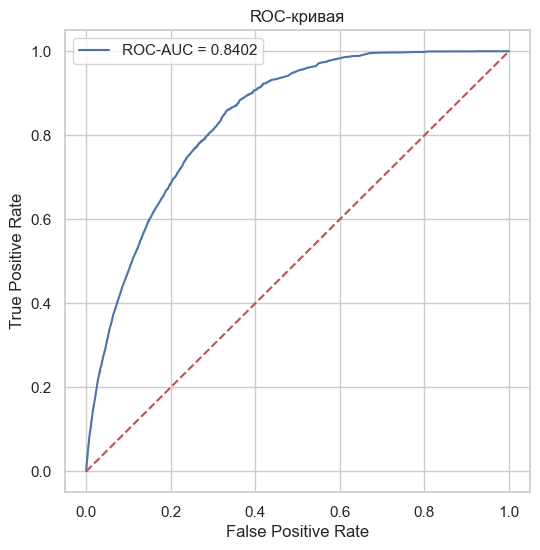

,Feature,Importance
3,event_count,0.342623
1,hits_count,0.319114
2,pages_count,0.209175
0,visit_number,0.034185
45,utm_medium_referral,0.020836
18,utm_medium_cpm,0.011286
61,device_os_Android,0.010962
70,device_os_Windows,0.007604
17,utm_medium_cpc,0.005704
72,device_os_iOS,0.003831


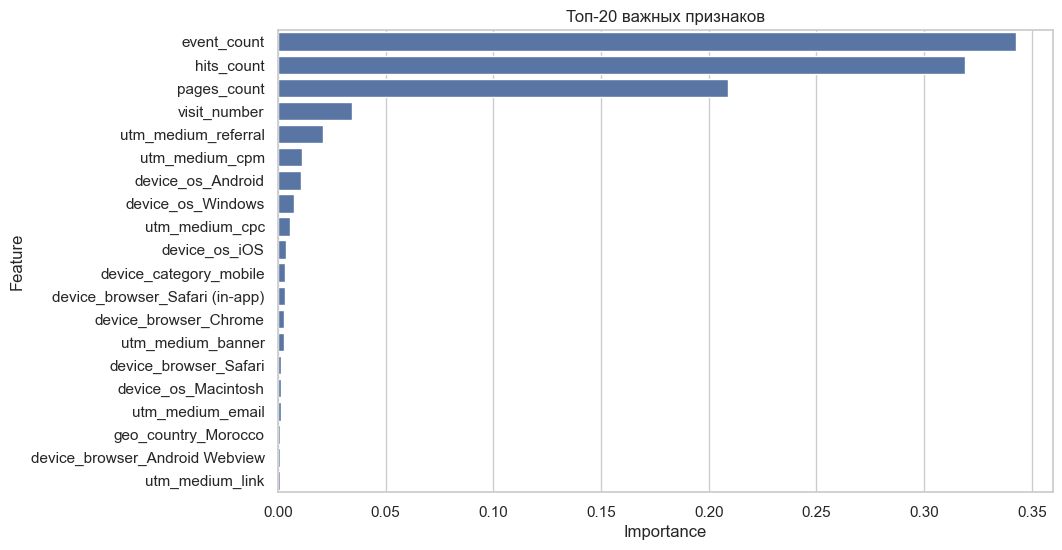

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(20), x="Importance", y="Feature")
plt.title("Топ-20 важных признаков")
plt.show()

**Итоговый вывод**

В ходе работы были объединены данные по визитам и агрегированные данные по событиям, выполнен разведочный анализ и построена модель классификации.  
Лучший результат показала модель RandomForestClassifier с ROC-AUC = 0.8402.  
Наиболее важными признаками оказались event_count, hits_count, pages_count и visit_number.